<h1><b>Aujourd'hui on approfondit les statistiques inférentielles — on passe des descriptions à la prise de décision basée sur les données !</b></h1>

<h2><b> 🎯 Objectif du jour</h2>
<h3><b>Maîtriser les tests statistiques et l'inférence — les outils qui permettent de prendre des décisions data-driven !</b></h3></h2>

<h4> <b style="color: blue">Setup et dataset :</b></h4>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Dataset : une entreprise de livraison camerounaise
n = 500
df = pd.DataFrame({
    "commande_id": range(1, n+1),
    "delai_livraison": np.random.normal(48, 12, n).round(1),  # heures
    "satisfaction": np.random.randint(1, 6, n),
    "montant": np.random.exponential(15000, n).round(0),
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"], n),
    "type_livraison": np.random.choice(["Standard", "Express"], n, p=[0.7, 0.3]),
    "incident": np.random.choice([0, 1], n, p=[0.85, 0.15])  # 15% d'incidents
})

print("=== APERÇU DU DATASET ===")
print(df.head())
print(f"\nShape : {df.shape}")
print(f"\nStatistiques délai :")
print(df["delai_livraison"].describe().round(2))

=== APERÇU DU DATASET ===
   commande_id  delai_livraison  satisfaction  montant      ville  \
0            1             54.0             2  21933.0     Douala   
1            2             46.3             2   8113.0     Garoua   
2            3             55.8             3   8206.0    Yaoundé   
3            4             66.3             3  20067.0     Garoua   
4            5             45.2             5   4092.0  Bafoussam   

  type_livraison  incident  
0       Standard         0  
1       Standard         0  
2       Standard         1  
3        Express         0  
4       Standard         0  

Shape : (500, 7)

Statistiques délai :
count    500.00
mean      48.08
std       11.78
min        9.10
25%       39.60
50%       48.20
75%       55.62
max       94.20
Name: delai_livraison, dtype: float64


<p>Aujourd'hui on travaille sur des données de livraison — on va répondre à des questions business concrètes comme : <br>"La livraison Express est-elle vraiment plus rapide ?" ou "Le taux d'incidents est-il le même dans toutes les villes ?"</p>

<h4> <b style="color: blue"> Échantillonnage :</b></h4>

=== POPULATION COMPLÈTE (500 commandes) ===
Moyenne     : 48.08 heures
Écart-type  : 11.78 heures

=== VARIABILITÉ DES ÉCHANTILLONS ===
n=  10 | Moyenne=55.94 | Erreur=7.86 heures
n=  30 | Moyenne=52.34 | Erreur=4.25 heures
n=  50 | Moyenne=50.45 | Erreur=2.36 heures
n= 100 | Moyenne=48.26 | Erreur=0.18 heures
n= 200 | Moyenne=47.94 | Erreur=0.15 heures


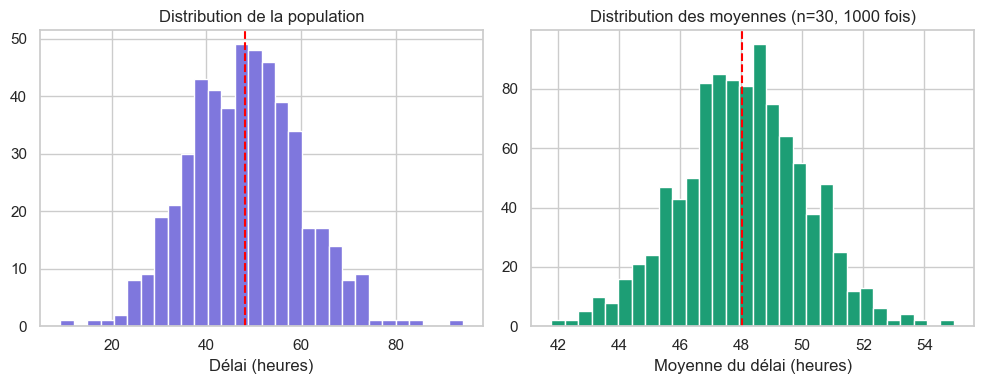

In [6]:
# Population complète vs échantillon
population = df["delai_livraison"]

print("=== POPULATION COMPLÈTE (500 commandes) ===")
print(f"Moyenne     : {population.mean():.2f} heures")
print(f"Écart-type  : {population.std():.2f} heures")

# Tirer plusieurs échantillons et observer la variabilité
print("\n=== VARIABILITÉ DES ÉCHANTILLONS ===")
for taille in [10, 30, 50, 100, 200]:
    echantillon = population.sample(taille, random_state=42)
    erreur = abs(echantillon.mean() - population.mean())
    print(f"n={taille:4d} | Moyenne={echantillon.mean():.2f} | "
          f"Erreur={erreur:.2f} heures")

# Visualiser la distribution des moyennes (Théorème Central Limite)
moyennes = [population.sample(30).mean() for _ in range(1000)]# “Je prends 30 personnes au hasard, je calcule leur moyenne.Je recommence 1000 fois pour voir comment les moyennes varient.”

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(population, bins=30, color="#7F77DD", edgecolor="white")
plt.axvline(population.mean(), color="red", linestyle="--")
plt.title("Distribution de la population")
plt.xlabel("Délai (heures)")

plt.subplot(1, 2, 2)
plt.hist(moyennes, bins=30, color="#1D9E75", edgecolor="white")
plt.axvline(np.mean(moyennes), color="red", linestyle="--")
plt.title("Distribution des moyennes (n=30, 1000 fois)")
plt.xlabel("Moyenne du délai (heures)")

plt.tight_layout()
plt.show()

<p><b>💡 Le Théorème Central Limite — </b>l'un des théorèmes les plus importants en statistiques :<br> quelle que soit la distribution de la population, la distribution des moyennes d'échantillons tend vers une distribution normale quand n est grand. <br>C'est le fondement de tous les tests statistiques !</p>

 <h4> <b style="color: blue"> Intervalles de confiance :</b></h4>

=== INTERVALLE DE CONFIANCE (95%) ===
Taille échantillon : 50
Moyenne            : 50.45 heures
Écart-type         : 11.23 heures
t critique         : 2.010
Marge d'erreur     : 3.19 heures
IC 95%             : [47.26 ; 53.64] heures

Interprétation : On est sûr à 95% que le délai moyen
réel se situe entre 47.3h et 53.6h


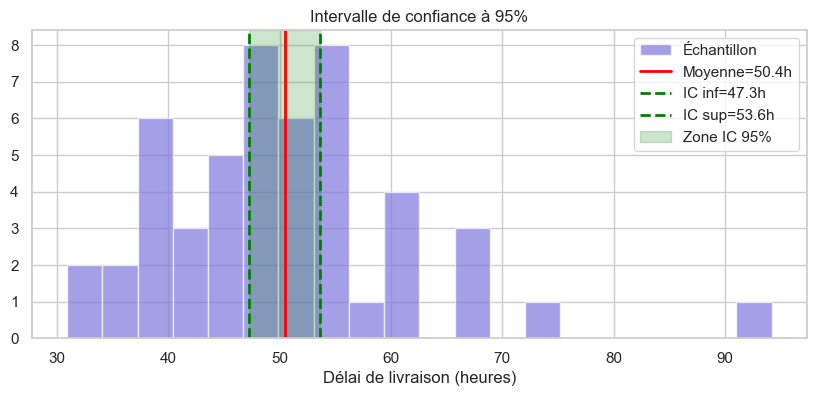

In [7]:
from scipy.stats import t, norm

# Intervalle de confiance pour le délai moyen
echantillon = df["delai_livraison"].sample(50, random_state=42)
n = len(echantillon)
moyenne = echantillon.mean()
ecart_type = echantillon.std()

# Intervalle de confiance à 95%
niveau_confiance = 0.95
alpha = 1 - niveau_confiance
t_critique = t.ppf(1 - alpha/2, df=n-1)
marge_erreur = t_critique * (ecart_type / np.sqrt(n))

ic_inf = moyenne - marge_erreur
ic_sup = moyenne + marge_erreur

print("=== INTERVALLE DE CONFIANCE (95%) ===")
print(f"Taille échantillon : {n}")
print(f"Moyenne            : {moyenne:.2f} heures")
print(f"Écart-type         : {ecart_type:.2f} heures")
print(f"t critique         : {t_critique:.3f}")
print(f"Marge d'erreur     : {marge_erreur:.2f} heures")
print(f"IC 95%             : [{ic_inf:.2f} ; {ic_sup:.2f}] heures")
print(f"\nInterprétation : On est sûr à 95% que le délai moyen")
print(f"réel se situe entre {ic_inf:.1f}h et {ic_sup:.1f}h")

# Visualiser l'intervalle de confiance
plt.figure(figsize=(10, 4))
plt.hist(echantillon, bins=20, color="#7F77DD", 
         edgecolor="white", alpha=0.7, label="Échantillon")
plt.axvline(moyenne, color="red", linewidth=2, label=f"Moyenne={moyenne:.1f}h")
plt.axvline(ic_inf, color="green", linestyle="--", 
            linewidth=2, label=f"IC inf={ic_inf:.1f}h")
plt.axvline(ic_sup, color="green", linestyle="--", 
            linewidth=2, label=f"IC sup={ic_sup:.1f}h")
plt.axvspan(ic_inf, ic_sup, alpha=0.2, color="green", label="Zone IC 95%")
plt.title("Intervalle de confiance à 95%")
plt.xlabel("Délai de livraison (heures)")
plt.legend()
plt.show()

<p><b>💡 L'intervalle de confiance répond à la question :</b> <br>"Dans quelle plage se trouve la vraie moyenne de la population ?" — Un IC à 95% signifie que si on répétait l'expérience 100 fois,<br> 95 fois sur 100 l'intervalle contiendrait la vraie moyenne !</p>

 <h3> <b style="color: black">Tests d'hypothèses !</b></h3>

<h4> <b style="color: blue">Le t-test : Express vraiment plus rapide ?</b></h4>

=== STATISTIQUES PAR TYPE DE LIVRAISON ===
Express  — Moyenne : 47.30h | n=154
Standard — Moyenne : 48.43h | n=346
Différence observée : 1.13h

=== HYPOTHÈSES ===
H0 (nulle)      : Express = Standard (pas de différence)
H1 (alternative): Express < Standard (Express plus rapide)

=== RÉSULTAT DU T-TEST ===
Statistique t : -0.9914
P-value       : 0.3220
Seuil alpha   : 0.05

Conclusion : On NE REJETTE PAS H0 — pas de différence significative
Impossible de prouver qu'Express est plus rapide


C:\Users\BARTHOLOMEW\AppData\Local\Temp\ipykernel_13436\1823698211.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([express, standard], labels=["Express", "Standard"],


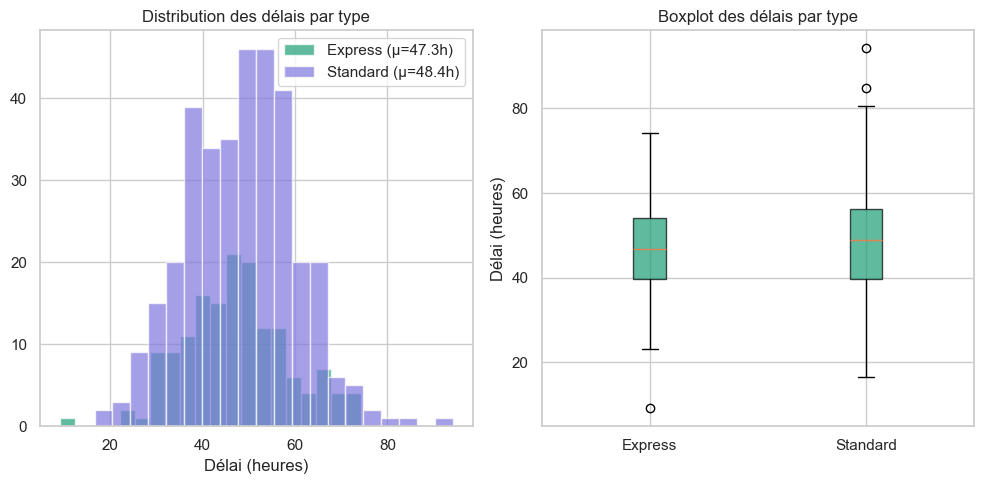

In [8]:
# Question business : La livraison Express est-elle vraiment plus rapide ?

express = df[df["type_livraison"] == "Express"]["delai_livraison"]
standard = df[df["type_livraison"] == "Standard"]["delai_livraison"]

print("=== STATISTIQUES PAR TYPE DE LIVRAISON ===")
print(f"Express  — Moyenne : {express.mean():.2f}h | n={len(express)}")
print(f"Standard — Moyenne : {standard.mean():.2f}h | n={len(standard)}")
print(f"Différence observée : {standard.mean() - express.mean():.2f}h")

# Formulation des hypothèses
print("\n=== HYPOTHÈSES ===")
print("H0 (nulle)      : Express = Standard (pas de différence)")
print("H1 (alternative): Express < Standard (Express plus rapide)")

# t-test bilatéral
stat, p_value = stats.ttest_ind(express, standard)
print("\n=== RÉSULTAT DU T-TEST ===")
print(f"Statistique t : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")
print(f"Seuil alpha   : 0.05")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0 — différence significative !")
    print("La livraison Express est statistiquement plus rapide ✓")
else:
    print("\nConclusion : On NE REJETTE PAS H0 — pas de différence significative")
    print("Impossible de prouver qu'Express est plus rapide")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(express, bins=20, alpha=0.7, color="#1D9E75", 
         label=f"Express (μ={express.mean():.1f}h)")
plt.hist(standard, bins=20, alpha=0.7, color="#7F77DD",
         label=f"Standard (μ={standard.mean():.1f}h)")
plt.title("Distribution des délais par type")
plt.xlabel("Délai (heures)")
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([express, standard], labels=["Express", "Standard"],
            patch_artist=True,
            boxprops=dict(facecolor="#1D9E75", alpha=0.7))
plt.title("Boxplot des délais par type")
plt.ylabel("Délai (heures)")
plt.tight_layout()
plt.show()

<p><b style ="color:red">💡 La logique du test d'hypothèse :</b><br>
<ul>
<li>H0 = hypothèse nulle → "rien ne se passe, pas de différence" </li>
<li>H1 = hypothèse alternative → "il y a une différence"</li>
<li>p-value < 0.05 → on rejette H0 → la différence est réelle</li>
<li>p-value > 0.05 → on ne peut pas rejeter H0 → différence due au hasard</li></ul></p>

<p><b>💡 Pourquoi la p-value > 0.05 ici ?</b> <br>
C'est parce que les deux groupes ont été générés avec la même distribution np.random.normal(48, 12, n)<br> — il n'y a donc pas de vraie différence dans nos données simulées. Dans la vraie vie, Express serait généralement plus rapide !</p>

<h4> <b style="color: blue">Test du Chi2 : le taux d'incidents dépend-il de la ville ?</b></h4>

=== TABLEAU DE CONTINGENCE ===
           Sans incident  Avec incident  Total
ville                                         
Bafoussam             94             17    111
Douala               116             16    132
Garoua               110             21    131
Yaoundé              107             19    126
All                  427             73    500

=== TAUX D'INCIDENTS PAR VILLE ===
Bafoussam    : 15.3%
Douala       : 12.1%
Garoua       : 16.0%
Yaoundé      : 15.1%

=== RÉSULTAT DU TEST CHI2 ===
Statistique Chi2 : 0.9343
Degrés de liberté: 3
P-value          : 0.8171
Seuil alpha      : 0.05

Conclusion : On NE REJETTE PAS H0
Le taux d'incidents est INDÉPENDANT de la ville


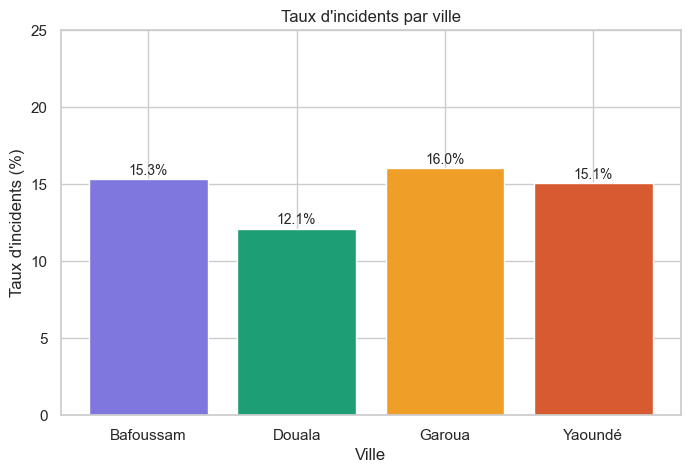

In [9]:
# Question business : Le taux d'incidents est-il le même dans toutes les villes ?

# Tableau de contingence
tableau = pd.crosstab(df["ville"], df["incident"], 
                      margins=True)
tableau.columns = ["Sans incident", "Avec incident", "Total"]
print("=== TABLEAU DE CONTINGENCE ===")
print(tableau)

# Taux d'incidents par ville
print("\n=== TAUX D'INCIDENTS PAR VILLE ===")
taux = df.groupby("ville")["incident"].mean() * 100
for ville, t in taux.items():
    print(f"{ville:12} : {t:.1f}%")

# Test du Chi2
tableau_chi2 = pd.crosstab(df["ville"], df["incident"])
chi2, p_value, ddl, attendues = stats.chi2_contingency(tableau_chi2)

print("\n=== RÉSULTAT DU TEST CHI2 ===")
print(f"Statistique Chi2 : {chi2:.4f}")
print(f"Degrés de liberté: {ddl}")
print(f"P-value          : {p_value:.4f}")
print(f"Seuil alpha      : 0.05")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0")
    print("Le taux d'incidents DÉPEND de la ville !")
else:
    print("\nConclusion : On NE REJETTE PAS H0")
    print("Le taux d'incidents est INDÉPENDANT de la ville")

# Visualisation
taux_plot = df.groupby("ville")["incident"].mean() * 100
plt.figure(figsize=(8, 5))
bars = plt.bar(taux_plot.index, taux_plot.values, 
               color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
for bar, val in zip(bars, taux_plot.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=10)
plt.title("Taux d'incidents par ville")
plt.xlabel("Ville")
plt.ylabel("Taux d'incidents (%)")
plt.ylim(0, 25)
plt.show()

<p><b>💡 Le test Chi2 </b>est utilisé pour tester l'indépendance entre deux variables catégorielles <br> — ici ville et incident. Il répond à la question : "La ville influence-t-elle le risque d'incident ?"</p>

<p><b>💡 Pourquoi ce résultat ?</b><br>
Encore une fois c'est parce que les incidents ont été générés avec la même probabilité <b> p=[0.85, 0.15] </b> pour toutes les villes <br>— donc pas de vraie différence. Dans la vraie vie, certaines villes pourraient avoir plus d'incidents à cause de la qualité des routes, du trafic, etc.</p>

<h3><b>ANOVA et tests non paramétriques !</b></h3>

<h4> <b style="color: blue">ANOVA : le délai varie-t-il selon la ville ?</b></h4>

=== DÉLAI MOYEN PAR VILLE ===
            mean    std  count
ville                         
Bafoussam  49.16  11.47    111
Douala     48.14  12.50    132
Garoua     47.66  11.51    131
Yaoundé    47.51  11.60    126

=== HYPOTHÈSES ANOVA ===
H0 : Les délais moyens sont ÉGAUX dans toutes les villes
H1 : Au moins une ville a un délai moyen DIFFÉRENT

=== RÉSULTAT ANOVA ===
Statistique F : 0.4611
P-value       : 0.7096

Conclusion : On NE REJETTE PAS H0
Pas de différence significative entre les villes


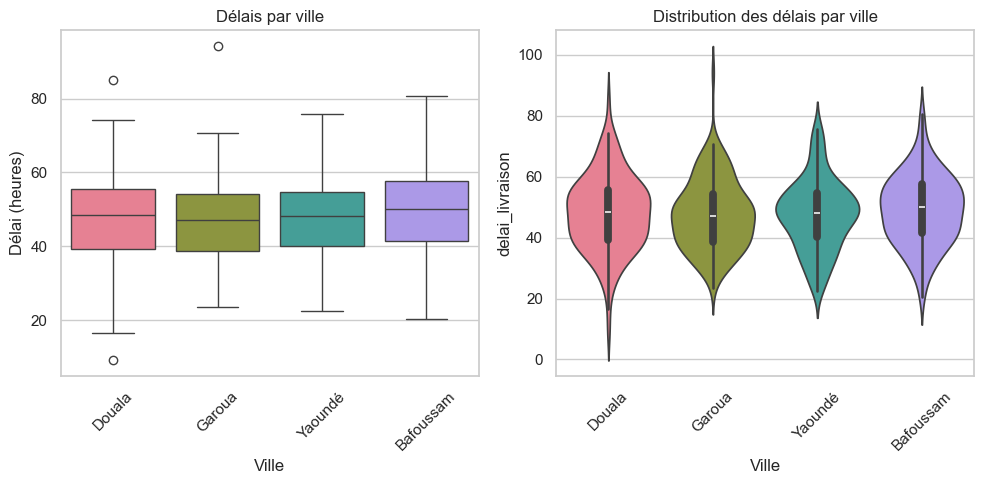

In [10]:
# Question business : Y a-t-il des différences de délai entre les villes ?

# Statistiques par ville
print("=== DÉLAI MOYEN PAR VILLE ===")
stats_ville = df.groupby("ville")["delai_livraison"].agg([
    "mean", "std", "count"
]).round(2)
print(stats_ville)

# Séparer les groupes
douala = df[df["ville"] == "Douala"]["delai_livraison"]
yaounde = df[df["ville"] == "Yaoundé"]["delai_livraison"]
bafoussam = df[df["ville"] == "Bafoussam"]["delai_livraison"]
garoua = df[df["ville"] == "Garoua"]["delai_livraison"]

# Formulation des hypothèses
print("\n=== HYPOTHÈSES ANOVA ===")
print("H0 : Les délais moyens sont ÉGAUX dans toutes les villes")
print("H1 : Au moins une ville a un délai moyen DIFFÉRENT")

# Test ANOVA
f_stat, p_value = stats.f_oneway(douala, yaounde, bafoussam, garoua)

print("\n=== RÉSULTAT ANOVA ===")
print(f"Statistique F : {f_stat:.4f}")
print(f"P-value       : {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0")
    print("Les délais sont significativement différents selon la ville !")
else:
    print("\nConclusion : On NE REJETTE PAS H0")
    print("Pas de différence significative entre les villes")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="ville", y="delai_livraison",
            hue="ville", legend=False, palette="husl")
plt.title("Délais par ville")
plt.xlabel("Ville")
plt.ylabel("Délai (heures)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.violinplot(data=df, x="ville", y="delai_livraison",
               hue="ville", legend=False, palette="husl")
plt.title("Distribution des délais par ville")
plt.xlabel("Ville")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<p><b>💡 L'ANOVA (Analysis of Variance)</b> est l'extension du <b>t-test</b> pour plus de 2 groupes — au lieu de comparer 2 moyennes, <br>elle compare simultanément les moyennes de plusieurs groupes. C'est beaucoup plus efficace que faire plusieurs t-tests ! 😄</p>

<h5> <b>Interpretation</b></h5>

<p>question métier: le délai varie-t-il selon la ville ?
1 ere remarque la variable ville a plus de 2 modalité donc l'ANOVA est plus approprié .<br>
hypothese:
H0: le statuquo: on va supposer que les delais moyens sont les memes dans toutes les villes.<br>
H1: (Alternative): Au moins un delai moyen est different<br>
P=0.7096>0.05 -> On ne rejette pas H0 donc les delais moyens sont les memes dans toutes les villes. En conclusion lee delai ne depend pas de la ville.<br> Mais dans la vraie vie c est le contraire car les villes n ont pas les memes distances et non plus le meme etat de la route</p>

<h4> <b style="color: blue">Tests non paramétriques :</b></h4>

In [11]:
# Quand utiliser les tests non paramétriques ?
# → Quand les données ne suivent PAS une distribution normale
# → Quand les échantillons sont petits (n < 30)

print("=== TESTS NON PARAMÉTRIQUES ===")
print("Utilisés quand les conditions du t-test ne sont pas remplies\n")

# Test de Mann-Whitney (alternative non paramétrique au t-test)
# Question : La satisfaction diffère-t-elle entre Express et Standard ?
express_sat = df[df["type_livraison"] == "Express"]["satisfaction"]
standard_sat = df[df["type_livraison"] == "Standard"]["satisfaction"]

print("=== MANN-WHITNEY : Satisfaction Express vs Standard ===")
print(f"Express  — Médiane : {express_sat.median():.1f} | n={len(express_sat)}")
print(f"Standard — Médiane : {standard_sat.median():.1f} | n={len(standard_sat)}")

stat, p_value = stats.mannwhitneyu(express_sat, standard_sat)
print(f"\nStatistique U : {stat:.0f}")
print(f"P-value       : {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion : Différence significative de satisfaction !")
else:
    print("Conclusion : Pas de différence significative de satisfaction")

# Test de Kruskal-Wallis (alternative non paramétrique à l'ANOVA)
# Question : La satisfaction varie-t-elle selon la ville ?
print("\n=== KRUSKAL-WALLIS : Satisfaction par ville ===")
groupes = [df[df["ville"] == v]["satisfaction"] for v in df["ville"].unique()]
stat, p_value = stats.kruskal(*groupes)
print(f"Statistique H : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion : Satisfaction significativement différente selon la ville !")
else:
    print("Conclusion : Pas de différence significative de satisfaction entre villes")

# Résumé des tests
print("\n=== RÉSUMÉ — QUEL TEST UTILISER ? ===")
resume_tests = pd.DataFrame({
    "Situation": [
        "2 groupes, données normales",
        "2 groupes, données non normales",
        "3+ groupes, données normales",
        "3+ groupes, données non normales",
        "2 variables catégorielles"
    ],
    "Test": [
        "t-test",
        "Mann-Whitney",
        "ANOVA",
        "Kruskal-Wallis",
        "Chi2"
    ],
    "Fonction scipy": [
        "stats.ttest_ind()",
        "stats.mannwhitneyu()",
        "stats.f_oneway()",
        "stats.kruskal()",
        "stats.chi2_contingency()"
    ]
})
print(resume_tests.to_string(index=False))

=== TESTS NON PARAMÉTRIQUES ===
Utilisés quand les conditions du t-test ne sont pas remplies

=== MANN-WHITNEY : Satisfaction Express vs Standard ===
Express  — Médiane : 3.0 | n=154
Standard — Médiane : 3.0 | n=346

Statistique U : 24466
P-value       : 0.1366
Conclusion : Pas de différence significative de satisfaction

=== KRUSKAL-WALLIS : Satisfaction par ville ===
Statistique H : 0.7116
P-value       : 0.8705
Conclusion : Pas de différence significative de satisfaction entre villes

=== RÉSUMÉ — QUEL TEST UTILISER ? ===
                       Situation           Test           Fonction scipy
     2 groupes, données normales         t-test        stats.ttest_ind()
 2 groupes, données non normales   Mann-Whitney     stats.mannwhitneyu()
    3+ groupes, données normales          ANOVA         stats.f_oneway()
3+ groupes, données non normales Kruskal-Wallis          stats.kruskal()
       2 variables catégorielles           Chi2 stats.chi2_contingency()


<p><h5>💡 Paramétrique vs Non paramétrique :</h5>

Paramétrique → suppose une distribution normale — plus puissant si l'hypothèse est vérifiée <br>
Non paramétrique → aucune hypothèse sur la distribution — plus robuste mais moins puissant<br>

En data science on vérifie toujours la normalité avant de choisir le test ! 

<h2 style "color: red ">Exercice pratique ! </h2>

<h3><b>Contexte :</b> Tu es data scientist dans une chaîne de restaurants camerounaise. Le directeur veut prendre des décisions basées sur les données.</h3>

=== INTERVALLE DE CONFIANCE (95%) ===
Taille échantillon : 60
Moyenne            : 25.93 minutes
Écart-type         : 8.73 minutes
t critique         : 2.001
Marge d'erreur     : 2.26 minutes
IC 95%             : [23.67 ; 28.18] minutes

Interprétation : On est sûr à 95% que le temps de preparation moyen
réel se situe entre 23.7m et 28.2m


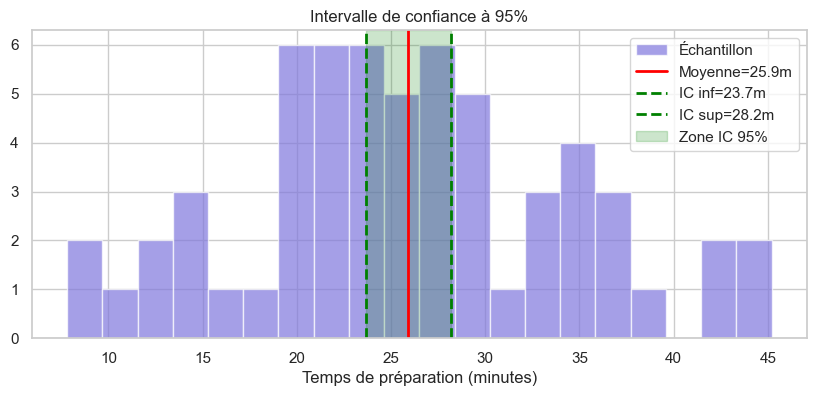

=== STATISTIQUES PAR WEEKEND ET PAR SEMAINE ===
Semaine  — Moyenne : 7934.11min | n=240
Weekend — Moyenne : 7847.06min | n=160
Différence observée : -87.05min

=== HYPOTHÈSES ===
H0 (nulle)      : Le montant moyen du Weenkend = Semaine (pas de différence)
H1 (alternative):Le montant moyen du Weenkend est different de celui de la Semaine (il existe au moins une différence)

=== RÉSULTAT DU T-TEST ===
Statistique t : 0.2780
P-value       : 0.7812
Seuil alpha   : 0.05

Conclusion : On NE REJETTE PAS H0
Pas de différence significative entre weekend et semaine


C:\Users\BARTHOLOMEW\AppData\Local\Temp\ipykernel_13436\3841575553.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([Semaine, Weekend], labels=["Semaine", "Weekend"],


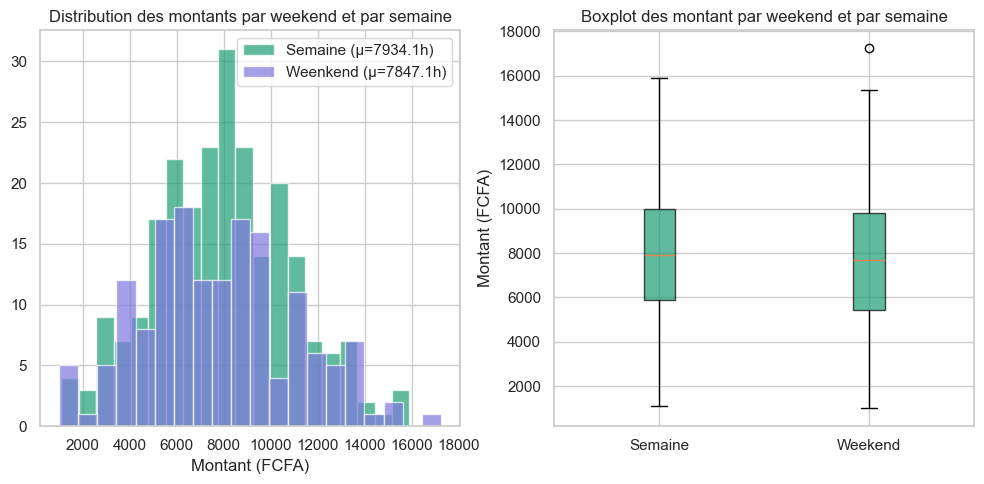

=== TABLEAU DE CONTINGENCE ===
              Sur place  A emporter  Livraison  Total
type_plat                                            
Fast-food            43          44         46    133
Grillades            47          27         43    117
Traditionnel         55          53         42    150
All                 145         124        131    400

=== HYPOTHÈSES ===
H0 (nulle)      : Le type de plat choisi est independant du mode de livraison (le choix du type de plat n'a rien avoir avecc la livraison)
H1 : Le type de plat choisi DÉPEND du mode de livraison
     (il existe une association entre les deux variables)

=== RÉSULTAT DU TEST CHI2 ===
Statistique Chi2 : 6.2735
Degrés de liberté: 4
P-value          : 0.1796
Seuil alpha      : 0.05

Conclusion : On NE REJETTE PAS H0
Le type de plat choisi est independant du mode de livraison. La differencce observée est dû au hasard


<Figure size 800x500 with 0 Axes>

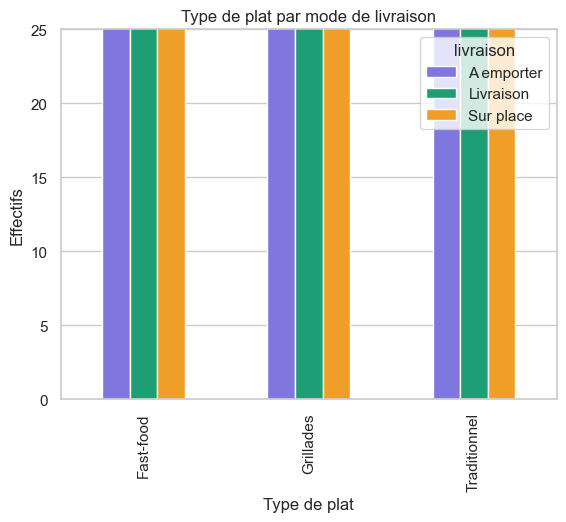

=== TEMPS DE PREPARATION MOYEN PAR RESTAURANT ===
                 mean   std  count
restaurant                        
Douala_Akwa     25.45  7.60     86
Douala_Centre   26.41  7.72     95
Yaoundé_Bastos  26.38  8.93    115
Yaoundé_Centre  26.35  7.18    104

=== HYPOTHÈSES ANOVA ===
H0 : Les temps de preparation moyens sont egaux dans tous les restaurants
H1 : Au moins un temps de preparation a un delai different des autres

=== RÉSULTAT ANOVA ===
Statistique F : 0.3084
P-value       : 0.8193

Conclusion : On NE REJETTE PAS H0
Pas de différence significative entre les restaurants


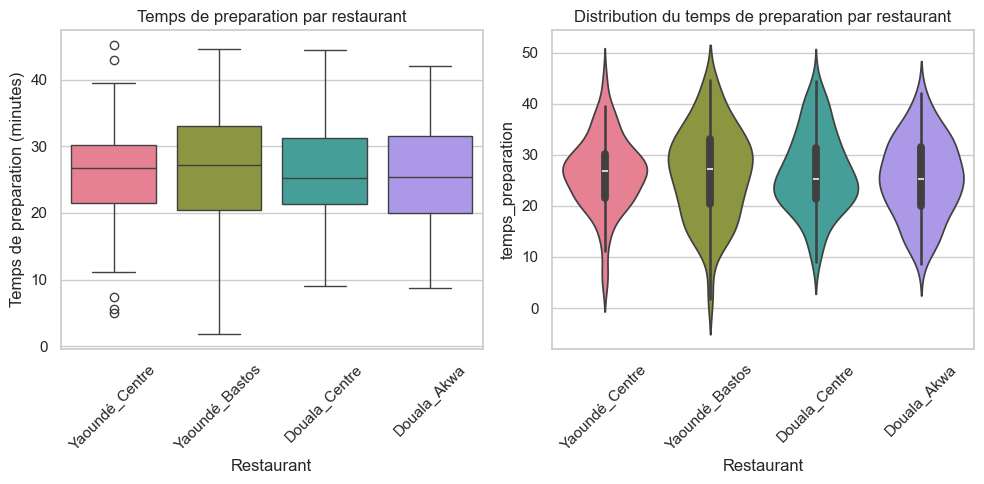

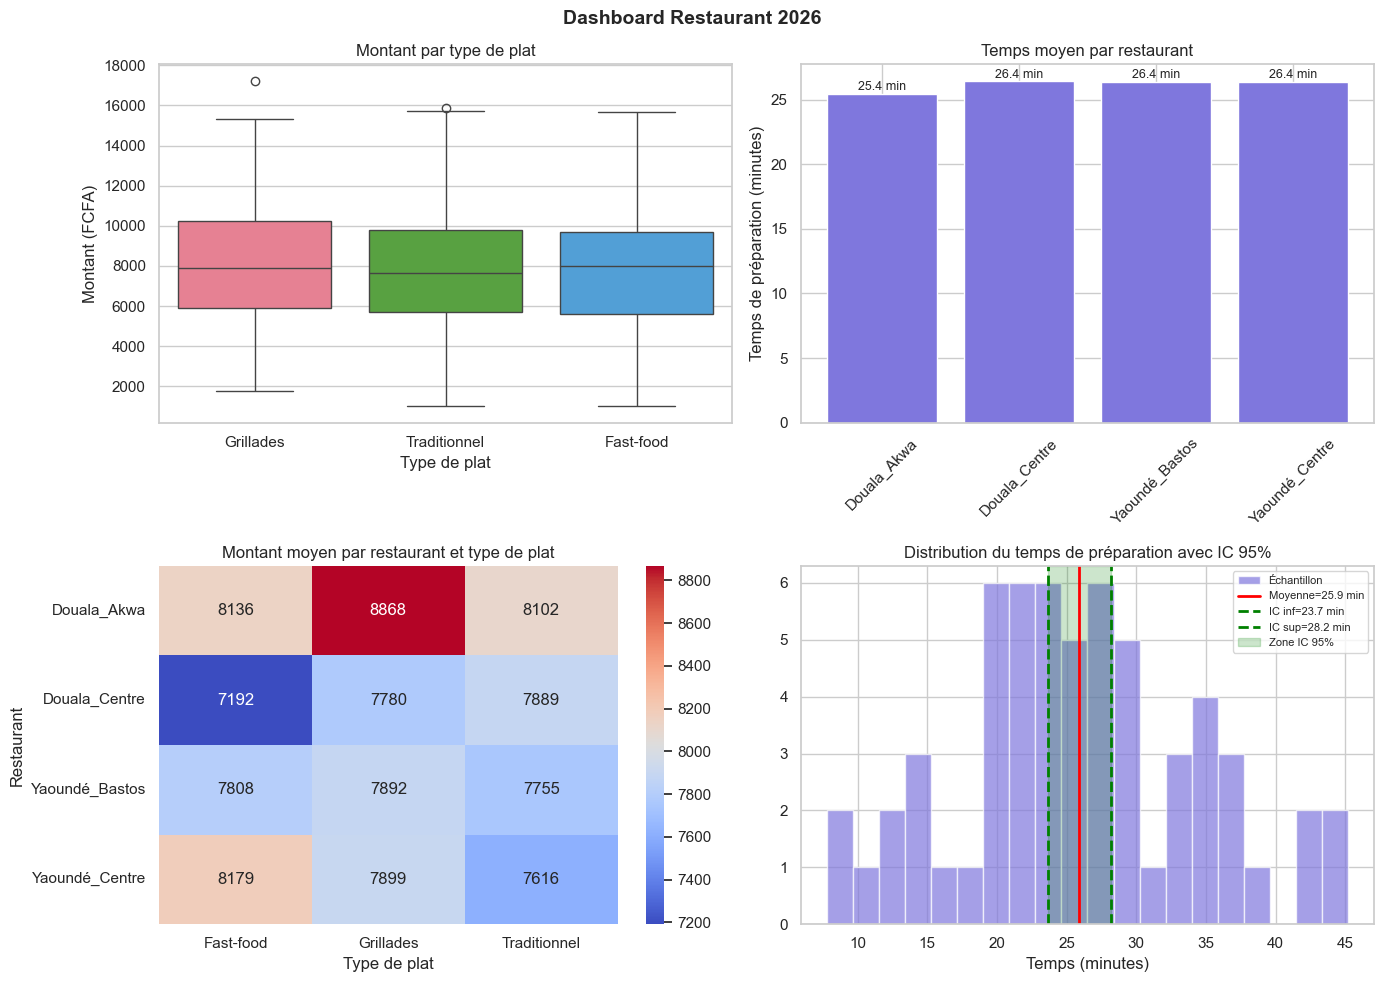


[OK] Dashboard sauvegardé !


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t as student_t
np.random.seed(42)
n = 400

df_resto = pd.DataFrame({
    "commande_id": range(1, n+1),
    "restaurant": np.random.choice(["Douala_Centre", "Douala_Akwa", 
                                    "Yaoundé_Centre", "Yaoundé_Bastos"], n),
    "type_plat": np.random.choice(["Traditionnel", "Fast-food", "Grillades"], n),
    "montant": np.random.normal(8000, 3000, n).astype(int).clip(1000),
    "temps_preparation": np.random.normal(25, 8, n).round(1),  # minutes
    "satisfaction": np.random.randint(1, 6, n),
    "livraison": np.random.choice(["Sur place", "A emporter", "Livraison"], n),
    "weekend": np.random.choice([0, 1], n, p=[0.6, 0.4])
})
#1- Intervalle de confiance : Calcule l'IC à 95% du temps de préparation moyen sur un échantillon de 60 commandes

# Intervalle de confiance pour le temps de préparation moyen
echantillon = df_resto["temps_preparation"].sample(60, random_state=42)
n = len(echantillon)
moyenne = echantillon.mean()
ecart_type = echantillon.std()
# Intervalle de confiance à 95%
niveau_confiance = 0.95
alpha = 1 - niveau_confiance
t_critique = student_t.ppf(1 - alpha/2, df=n-1)
marge_erreur = t_critique * (ecart_type / np.sqrt(n))
ic_inf = moyenne - marge_erreur
ic_sup = moyenne + marge_erreur

print("=== INTERVALLE DE CONFIANCE (95%) ===")
print(f"Taille échantillon : {n}")
print(f"Moyenne            : {moyenne:.2f} minutes")
print(f"Écart-type         : {ecart_type:.2f} minutes")
print(f"t critique         : {t_critique:.3f}")
print(f"Marge d'erreur     : {marge_erreur:.2f} minutes")
print(f"IC 95%             : [{ic_inf:.2f} ; {ic_sup:.2f}] minutes")
print(f"\nInterprétation : On est sûr à 95% que le temps de preparation moyen")
print(f"réel se situe entre {ic_inf:.1f}m et {ic_sup:.1f}m")

# Visualiser l'intervalle de confiance
plt.figure(figsize=(10, 4))
plt.hist(echantillon, bins=20, color="#7F77DD", 
         edgecolor="white", alpha=0.7, label="Échantillon")
plt.axvline(moyenne, color="red", linewidth=2, label=f"Moyenne={moyenne:.1f}m")
plt.axvline(ic_inf, color="green", linestyle="--", 
            linewidth=2, label=f"IC inf={ic_inf:.1f}m")
plt.axvline(ic_sup, color="green", linestyle="--", 
            linewidth=2, label=f"IC sup={ic_sup:.1f}m")
plt.axvspan(ic_inf, ic_sup, alpha=0.2, color="green", label="Zone IC 95%")
plt.title("Intervalle de confiance à 95%")
plt.xlabel("Temps de préparation (minutes)")
plt.legend()
plt.show()

#2- T-test : Le montant moyen est-il différent entre le weekend et la semaine ?
# Séparer correctement
Semaine = df_resto[df_resto["weekend"] == 0]["montant"]
Weekend = df_resto[df_resto["weekend"] == 1]["montant"]

print("=== STATISTIQUES PAR WEEKEND ET PAR SEMAINE ===")
print(f"Semaine  — Moyenne : {Semaine.mean():.2f}min | n={len(Semaine)}")
print(f"Weekend — Moyenne : {Weekend.mean():.2f}min | n={len(Weekend)}")
print(f"Différence observée : {Weekend.mean() - Semaine.mean():.2f}min")
# Formulation des hypothèses
print("\n=== HYPOTHÈSES ===")
print("H0 (nulle)      : Le montant moyen du Weenkend = Semaine (pas de différence)")
print("H1 (alternative):Le montant moyen du Weenkend est different de celui de la Semaine (il existe au moins une différence)")

# t-test bilatéral
stat, p_value = stats.ttest_ind(Semaine,Weekend)
print("\n=== RÉSULTAT DU T-TEST ===")
print(f"Statistique t : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")
print(f"Seuil alpha   : 0.05")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0 — différence significative !")
    print("Le montant moyen du weekend est DIFFÉRENT de celui de la semaine")
else:
    print("\nConclusion : On NE REJETTE PAS H0")
    print("Pas de différence significative entre weekend et semaine")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(Semaine, bins=20, alpha=0.7, color="#1D9E75", 
         label=f"Semaine (μ={Semaine.mean():.1f}h)")
plt.hist(Weekend, bins=20, alpha=0.7, color="#7F77DD",
         label=f"Weenkend (μ={Weekend.mean():.1f}h)")
plt.title("Distribution des montants par weekend et par semaine")
plt.xlabel("Montant (FCFA)")
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([Semaine, Weekend], labels=["Semaine", "Weekend"],
            patch_artist=True,
            boxprops=dict(facecolor="#1D9E75", alpha=0.7))
plt.title("Boxplot des montant par weekend et par semaine")
plt.ylabel("Montant (FCFA)")
plt.tight_layout()
plt.show()

#Chi2 - Question business :Le type de plat choisi dépend-il du mode de livraison ?
# Tableau de contingence
tableau = pd.crosstab(df_resto["type_plat"], df_resto["livraison"], 
                      margins=True)
tableau.columns = ["Sur place", "A emporter", "Livraison", "Total"]
print("=== TABLEAU DE CONTINGENCE ===")
print(tableau)

# Test du Chi2
tableau_chi2 = pd.crosstab(df_resto["type_plat"], df_resto["livraison"])
chi2, p_value, ddl, attendues = stats.chi2_contingency(tableau_chi2)
print("\n=== HYPOTHÈSES ===")
print("H0 (nulle)      : Le type de plat choisi est independant du mode de livraison (le choix du type de plat n'a rien avoir avecc la livraison)")
print("H1 : Le type de plat choisi DÉPEND du mode de livraison")
print("     (il existe une association entre les deux variables)")
print("\n=== RÉSULTAT DU TEST CHI2 ===")
print(f"Statistique Chi2 : {chi2:.4f}")
print(f"Degrés de liberté: {ddl}")
print(f"P-value          : {p_value:.4f}")
print(f"Seuil alpha      : 0.05")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0")
    print("Le type de plat choisi depend du mode de livraison!")
else:
    print("\nConclusion : On NE REJETTE PAS H0")
    print("Le type de plat choisi est independant du mode de livraison. La differencce observée est dû au hasard")

# Visualisation
plt.figure(figsize=(8, 5))
tableau_chi2.plot(kind="bar", color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
plt.title("Type de plat par mode de livraison")
plt.xlabel("Type de plat")
plt.ylabel("Effectifs")
plt.ylim(0, 25)
plt.show()

#4- ANOVA-Question business : Le temps de préparation varie-t-il selon le restaurant ?
# Statistiques par ville
print("=== TEMPS DE PREPARATION MOYEN PAR RESTAURANT ===")
stats_resto = df_resto.groupby("restaurant")["temps_preparation"].agg([
    "mean", "std", "count"
]).round(2)
print(stats_resto)

# Séparer les groupes
douala_Centre = df_resto[df_resto["restaurant"] == "Douala_Centre"]["temps_preparation"]
douala_Akwa = df_resto[df_resto["restaurant"] == "Douala_Akwa"]["temps_preparation"]
yaoundé_Centre = df_resto[df_resto["restaurant"] == "Yaoundé_Centre"]["temps_preparation"]
yaoundé_Bastos = df_resto[df_resto["restaurant"] == "Yaoundé_Bastos"]["temps_preparation"]

# Formulation des hypothèses
print("\n=== HYPOTHÈSES ANOVA ===")
print("H0 : Les temps de preparation moyens sont egaux dans tous les restaurants")
print("H1 : Au moins un temps de preparation a un delai different des autres")

# Test ANOVA
f_stat, p_value = stats.f_oneway(douala_Centre, douala_Akwa, yaoundé_Centre, yaoundé_Bastos)

print("\n=== RÉSULTAT ANOVA ===")
print(f"Statistique F : {f_stat:.4f}")
print(f"P-value       : {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion : On REJETTE H0")
    print("Les tesmps moyens de preparations sont significativement différents selon le restaurant !")
else:
    print("\nConclusion : On NE REJETTE PAS H0")
    print("Pas de différence significative entre les restaurants")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_resto, x="restaurant", y="temps_preparation",
            hue="restaurant", legend=False, palette="husl")
plt.title("Temps de preparation par restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Temps de preparation (minutes)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.violinplot(data=df_resto, x="restaurant", y="temps_preparation",
               hue="restaurant", legend=False, palette="husl")
plt.title("Distribution du temps de preparation par restaurant")
plt.xlabel("Restaurant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#5- Dashboard
import os
os.makedirs("jour08/output", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot du montant par type de plat
sns.boxplot(data=df_resto, x="type_plat", y="montant",
            hue="type_plat", legend=False,
            palette="husl", ax=axes[0,0])
axes[0,0].set_title("Montant par type de plat")
axes[0,0].set_ylabel("Montant (FCFA)")
axes[0,0].set_xlabel("Type de plat")

# 2. Barplot du temps moyen par restaurant
temps_moy = df_resto.groupby("restaurant")["temps_preparation"].mean().round(2)
axes[0,1].bar(temps_moy.index, temps_moy.values, color="#7F77DD")
axes[0,1].set_title("Temps moyen par restaurant")
axes[0,1].set_ylabel("Temps de préparation (minutes)")
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(temps_moy.values):
    axes[0,1].text(i, v + 0.3, f"{v:.1f} min", ha="center", fontsize=9)

# 3. Heatmap montant moyen par restaurant et type de plat
pivot = df_resto.pivot_table(
    values="montant",
    index="restaurant",
    columns="type_plat",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, fmt=".0f",
            cmap="coolwarm", ax=axes[1,0])
axes[1,0].set_title("Montant moyen par restaurant et type de plat")
axes[1,0].set_xlabel("Type de plat")
axes[1,0].set_ylabel("Restaurant")

# 4. Distribution du temps de préparation avec IC
axes[1,1].hist(echantillon, bins=20, color="#7F77DD",
               edgecolor="white", alpha=0.7, label="Échantillon")
axes[1,1].axvline(moyenne, color="red", linewidth=2,
                  label=f"Moyenne={moyenne:.1f} min")
axes[1,1].axvline(ic_inf, color="green", linestyle="--",
                  linewidth=2, label=f"IC inf={ic_inf:.1f} min")
axes[1,1].axvline(ic_sup, color="green", linestyle="--",
                  linewidth=2, label=f"IC sup={ic_sup:.1f} min")
axes[1,1].axvspan(ic_inf, ic_sup, alpha=0.2, color="green", label="Zone IC 95%")
axes[1,1].set_title("Distribution du temps de préparation avec IC 95%")
axes[1,1].set_xlabel("Temps (minutes)")
axes[1,1].legend(fontsize=8)

plt.suptitle("Dashboard Restaurant 2026", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("jour08/output/dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[OK] Dashboard sauvegardé !")

<p> 
<h3><b>Questions business à répondre :</b></h3>
<ol>
<li>Intervalle de confiance : Calcule l'IC à 95% du temps de préparation moyen sur un échantillon de 60 commandes</li>
<li>T-test : Le montant moyen est-il différent entre le weekend et la semaine ?</li>
<li>Chi2 : Le type de plat choisi dépend-il du mode de livraison ?</li>
<li>ANOVA : Le temps de préparation varie-t-il selon le restaurant ?</li>
<li>    Visualisation : Trace un dashboard avec :</li>
<ul>
<li>Boxplot du montant par type de plat</li>
<li>Barplot du temps moyen par restaurant</li>
<li>Heatmap du montant moyen par restaurant et type de plat (pivot table)</li>
<li>Distribution du temps de préparation avec IC</li></ul>
</ol>
</P>

<p> <b style="color:red">💡 Les 3 leçons importantes de cet exercice : </b> <br>
<ol>
<li>Toujours vérifier que les bonnes variables sont utilisées dans les graphiques</li>
<li>La conclusion doit être cohérente avec la décision sur H0 </li>
<li>La heatmap dans un dashboard doit toujours avoir ax=axes<b style="color:blue">[i,j] </b> sinon elle crée une nouvelle figure !</li></ol> </P>

<P> <h3>✅ Bilan du Jour 8 </h3>

<h5>Tu as maîtrisé aujourd'hui :</h5><ol>
<li>✅ Échantillonnage et Théorème Central Limite</li>
<li>✅ Intervalles de confiance à 95% </li>
<li>✅ T-test — comparer 2 groupes </li>
<li>✅ Test du Chi2 — indépendance entre variables catégorielles </li>
<li>✅ ANOVA — comparer 3+ groupes </li>
<li>✅ Tests non paramétriques (Mann-Whitney, Kruskal-Wallis) </li>
<li>✅ Formulation correcte des hypothèses H0/H1 </li>
<li>✅ Exercice restaurant complété 💪</li></ol</P>
<p> <b>💡 La compétence clé du jour : tu sais maintenant choisir le bon test statistique selon la situation <br>— c'est une compétence que beaucoup de data scientists n'ont pas !</b></p>